# Эксперименты с моделями

В этом ноутбуке выполняется: сравнение нескольких моделей, ансамблей, вариантов feature engineering и экспериментов с уменьшением размерности.

На baseline-этапе уже были получены результаты Logistic Regression и KNN без feature engineering. Здесь проверяются более сильные модели и гипотезы, которые будут описаны ниже.

In [15]:
from pathlib import Path
import sys
import warnings

from typing import Any, cast
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.base import BaseEstimator, clone
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.ensemble import (
    AdaBoostClassifier,
    ExtraTreesClassifier,
    HistGradientBoostingClassifier,
    RandomForestClassifier,
    StackingClassifier,
    VotingClassifier,
)
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import ParameterGrid, RandomizedSearchCV, StratifiedKFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.append(str(PROJECT_ROOT))

from src.preprocessing import (
    CATEGORICAL_FEATURES,
    NUMERIC_FEATURES,
    RANDOM_STATE,
    make_train_val_test_split,
    split_features_target,
)

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="Set2")

PROCESSED_DATA_PATH = PROJECT_ROOT / "data" / "processed" / "cardio_clean.csv"
BASELINE_RESULTS_PATH = PROJECT_ROOT / "report" / "tables" / "baseline_results.csv"
EXPERIMENT_PLAN_PATH = PROJECT_ROOT / "report" / "tables" / "advanced_experiments_plan.csv"
EXPERIMENT_RESULTS_PATH = PROJECT_ROOT / "report" / "tables" / "advanced_experiments_results.csv"
FINAL_RESULTS_PATH = PROJECT_ROOT / "report" / "tables" / "final_model_results.csv"
FIGURES_DIR = PROJECT_ROOT / "report" / "images"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
EXPERIMENT_PLAN_PATH.parent.mkdir(parents=True, exist_ok=True)

MAX_SEARCH_ITER = 12
CV_FOLDS = 3

RANDOM_STATE

42

## Загрузка данных и split

Используется очищенный датасет из первого этапа. Split выполняется той же функцией, что и в EDA/baseline: `train` 70%, `validation` 15%, `test` 15%, stratify по целевой переменной.

In [16]:
df_clean = pd.read_csv(PROCESSED_DATA_PATH)

x, y = split_features_target(df_clean)
x_train, x_val, x_test, y_train, y_val, y_test = make_train_val_test_split(x, y)

split_summary = pd.DataFrame(
    {
        "split": ["train", "validation", "test"],
        "rows": [len(x_train), len(x_val), len(x_test)],
        "positive_rate": [y_train.mean(), y_val.mean(), y_test.mean()],
    }
)

split_summary

,split,rows,positive_rate
0,train,48015,0.494762
1,validation,10289,0.494703
2,test,10290,0.494752


## Feature engineering

Новые признаки считаются только из исходных признаков одной строки, без использования target и без статистик по всему датасету. Поэтому такой feature engineering не создает утечку данных.

Добавим признаки:

- `age_years` - возраст в годах вместо дней;
- `bmi` - индекс массы тела;
- `pulse_pressure` - разница между систолическим и диастолическим давлением;
- `mean_arterial_pressure` - приближенное среднее артериальное давление;
- `pressure_ratio` - отношение `ap_hi / ap_lo`.

In [17]:
ENGINEERED_NUMERIC_FEATURES = [
    *NUMERIC_FEATURES,
    "age_years",
    "bmi",
    "pulse_pressure",
    "mean_arterial_pressure",
    "pressure_ratio",
]


def add_medical_features(df: pd.DataFrame) -> pd.DataFrame:
    data = df.copy()
    height_m = data["height"] / 100

    data["age_years"] = data["age"] / 365.25
    data["bmi"] = data["weight"] / (height_m**2)
    data["pulse_pressure"] = data["ap_hi"] - data["ap_lo"]
    data["mean_arterial_pressure"] = data["ap_lo"] + data["pulse_pressure"] / 3
    data["pressure_ratio"] = data["ap_hi"] / data["ap_lo"]

    return data


add_medical_features(x_train.head())

,age,height,weight,ap_hi,ap_lo,gender,cholesterol,gluc,smoke,alco,active,age_years,bmi,pulse_pressure,mean_arterial_pressure,pressure_ratio
38869,22875,180,72.0,120,80,2,1,1,0,0,1,62.628337,22.222222,40,93.333333,1.500000
7169,21218,152,55.0,130,90,1,1,1,1,0,1,58.091718,23.805402,40,103.333333,1.444444
51927,18683,169,69.0,110,80,1,1,1,0,0,1,51.151266,24.158818,30,90.000000,1.375000
6362,22735,162,72.0,150,100,2,1,2,1,0,1,62.245038,27.434842,50,116.666667,1.500000
5782,20508,161,78.0,140,90,1,1,1,0,0,1,56.147844,30.091432,50,106.666667,1.555556


## Общие функции для экспериментов

Ниже задаются preprocessor, pipeline, оценка метрик и функция запуска поиска гиперпараметров. Основная метрика для `RandomizedSearchCV`: `ROC-AUC`.

In [18]:
def one_hot_encoder() -> OneHotEncoder:
    return OneHotEncoder(handle_unknown="ignore", sparse_output=False)


def build_preprocessor(
    numeric_features: list[str],
    categorical_features: list[str],
    *,
    use_pca: bool = False,
    pca_components: int | float = 0.95,
) -> Pipeline | ColumnTransformer:
    numeric_pipeline = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]
    )
    categorical_pipeline = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("one_hot", one_hot_encoder()),
        ]
    )

    columns = ColumnTransformer(
        transformers=[
            ("numeric", numeric_pipeline, numeric_features),
            ("categorical", categorical_pipeline, categorical_features),
        ]
    )

    if not use_pca:
        return columns

    return Pipeline(
        steps=[
            ("columns", columns),
            ("pca", PCA(n_components=pca_components, random_state=RANDOM_STATE)),
        ]
    )


def build_experiment_pipeline(
    model: BaseEstimator,
    *,
    feature_mode: str = "raw",
    use_pca: bool = False,
    pca_components: int | float = 0.95,
) -> Pipeline:
    if feature_mode not in {"raw", "engineered"}:
        raise ValueError("feature_mode must be 'raw' or 'engineered'")

    numeric_features = NUMERIC_FEATURES if feature_mode == "raw" else ENGINEERED_NUMERIC_FEATURES

    steps: list[tuple[str, Any]] = []
    if feature_mode == "engineered":
        steps.append(("feature_engineering", FunctionTransformer(add_medical_features, validate=False)))

    steps.extend(
        [
            (
                "preprocessor",
                build_preprocessor(
                    numeric_features,
                    CATEGORICAL_FEATURES,
                    use_pca=use_pca,
                    pca_components=pca_components,
                ),
            ),
            ("model", model),
        ]
    )

    return Pipeline(steps=steps)


def evaluate_classifier(estimator: Pipeline, x_data: pd.DataFrame, y_true: pd.Series) -> dict[str, float]:
    y_pred = estimator.predict(x_data)

    metrics = {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
    }

    if hasattr(estimator, "predict_proba"):
        y_score = estimator.predict_proba(x_data)[:, 1]
    elif hasattr(estimator, "decision_function"):
        y_score = estimator.decision_function(x_data)
    else:
        y_score = y_pred

    metrics["roc_auc"] = roc_auc_score(y_true, y_score)
    return metrics


def count_grid_candidates(param_grid: dict[str, list[Any]]) -> int:
    if not param_grid:
        return 1
    return len(list(ParameterGrid(param_grid)))


def fit_experiment(experiment: dict[str, Any]) -> tuple[Pipeline, dict[str, Any]]:
    model = cast(BaseEstimator, experiment["model"])
    feature_mode = cast(str, experiment["feature_mode"])
    use_pca = cast(bool, experiment.get("use_pca", False))
    pca_components = cast(int | float, experiment.get("pca_components", 0.95))
    param_grid = cast(dict[str, list[Any]], experiment.get("param_grid", {}))

    pipeline = build_experiment_pipeline(
        clone(model),
        feature_mode=feature_mode,
        use_pca=use_pca,
        pca_components=pca_components,
    )

    cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)

    if param_grid:
        search = RandomizedSearchCV(
            estimator=pipeline,
            param_distributions=param_grid,
            n_iter=min(MAX_SEARCH_ITER, count_grid_candidates(param_grid)),
            scoring="roc_auc",
            cv=cv,
            n_jobs=-1,
            random_state=RANDOM_STATE,
            refit=True,
        )
        search.fit(x_train, y_train)
        best_estimator = cast(Pipeline, search.best_estimator_)
        search_info = {
            "best_cv_roc_auc": search.best_score_,
            "best_params": search.best_params_,
        }
    else:
        best_estimator = cast(Pipeline, pipeline.fit(x_train, y_train))
        search_info = {
            "best_cv_roc_auc": np.nan,
            "best_params": {},
        }

    return best_estimator, search_info

## План экспериментов

Фиксируем список экспериментов до сравнения результатов: модели, гипотезы, feature engineering, PCA и сетки гиперпараметров.

In [19]:
base_logreg = LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)
base_tree = DecisionTreeClassifier(max_depth=4, random_state=RANDOM_STATE, class_weight="balanced")
base_forest = RandomForestClassifier(
    n_estimators=200,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    class_weight="balanced_subsample",
)
base_histgb = HistGradientBoostingClassifier(random_state=RANDOM_STATE)

experiments: list[dict[str, Any]] = [
    {
        "experiment_id": "exp_01_logreg_raw_tuned",
        "model_name": "Logistic Regression tuned",
        "hypothesis": "Подбор регуляризации может улучшить baseline Logistic Regression.",
        "feature_mode": "raw",
        "use_pca": False,
        "model": base_logreg,
        "param_grid": {
            "model__C": [0.05, 0.1, 0.5, 1.0, 2.0, 5.0],
            "model__class_weight": [None, "balanced"],
        },
    },
    {
        "experiment_id": "exp_02_knn_raw_tuned",
        "model_name": "KNN tuned",
        "hypothesis": "KNN чувствителен к числу соседей, поэтому настройка k может улучшить baseline.",
        "feature_mode": "raw",
        "use_pca": False,
        "model": KNeighborsClassifier(),
        "param_grid": {
            "model__n_neighbors": [9, 15, 25, 35, 45],
            "model__weights": ["uniform", "distance"],
            "model__p": [1, 2],
        },
    },
    {
        "experiment_id": "exp_03_tree_engineered",
        "model_name": "Decision Tree",
        "hypothesis": "Неглубокое дерево проверяет простые нелинейные правила и взаимодействия признаков.",
        "feature_mode": "engineered",
        "use_pca": False,
        "model": DecisionTreeClassifier(random_state=RANDOM_STATE, class_weight="balanced"),
        "param_grid": {
            "model__max_depth": [3, 4, 5, 7, 10],
            "model__min_samples_leaf": [20, 50, 100, 200],
        },
    },
    {
        "experiment_id": "exp_04_random_forest_engineered",
        "model_name": "Random Forest",
        "hypothesis": "Бэггинг деревьев должен устойчивее ловить нелинейности, чем одно дерево.",
        "feature_mode": "engineered",
        "use_pca": False,
        "model": base_forest,
        "param_grid": {
            "model__n_estimators": [200, 400],
            "model__max_depth": [None, 8, 12, 18],
            "model__min_samples_leaf": [1, 3, 5, 10],
            "model__max_features": ["sqrt", "log2"],
        },
    },
    {
        "experiment_id": "exp_05_extra_trees_engineered",
        "model_name": "Extra Trees",
        "hypothesis": "Более случайные деревья могут дать меньшую дисперсию и сильный ансамбль.",
        "feature_mode": "engineered",
        "use_pca": False,
        "model": ExtraTreesClassifier(random_state=RANDOM_STATE, n_jobs=-1, class_weight="balanced"),
        "param_grid": {
            "model__n_estimators": [200, 400],
            "model__max_depth": [None, 8, 12, 18],
            "model__min_samples_leaf": [1, 3, 5, 10],
            "model__max_features": ["sqrt", "log2"],
        },
    },
    {
        "experiment_id": "exp_06_hist_gradient_boosting_engineered",
        "model_name": "HistGradientBoosting",
        "hypothesis": "Boosting может лучше использовать слабые нелинейные зависимости в медицинских признаках.",
        "feature_mode": "engineered",
        "use_pca": False,
        "model": base_histgb,
        "param_grid": {
            "model__learning_rate": [0.03, 0.05, 0.1],
            "model__max_iter": [100, 200, 300],
            "model__max_leaf_nodes": [15, 31, 63],
            "model__l2_regularization": [0.0, 0.01, 0.1],
        },
    },
    {
        "experiment_id": "exp_07_adaboost_engineered",
        "model_name": "AdaBoost",
        "hypothesis": "AdaBoost на слабых деревьях дает еще один вариант boosting для сравнения.",
        "feature_mode": "engineered",
        "use_pca": False,
        "model": AdaBoostClassifier(
            estimator=DecisionTreeClassifier(max_depth=1, random_state=RANDOM_STATE),
            random_state=RANDOM_STATE,
        ),
        "param_grid": {
            "model__n_estimators": [50, 100, 200],
            "model__learning_rate": [0.03, 0.05, 0.1, 0.5],
        },
    },
    {
        "experiment_id": "exp_08_logreg_engineered_pca",
        "model_name": "Logistic Regression + PCA",
        "hypothesis": "PCA может убрать корреляции после one-hot/FE и помочь линейной модели.",
        "feature_mode": "engineered",
        "use_pca": True,
        "pca_components": 0.95,
        "model": base_logreg,
        "param_grid": {
            "model__C": [0.05, 0.1, 0.5, 1.0, 2.0],
            "model__class_weight": [None, "balanced"],
        },
    },
    {
        "experiment_id": "exp_09_soft_voting_engineered",
        "model_name": "Soft Voting Ensemble",
        "hypothesis": "Усреднение вероятностей разных моделей может быть стабильнее одной модели.",
        "feature_mode": "engineered",
        "use_pca": False,
        "model": VotingClassifier(
            estimators=[
                ("logreg", base_logreg),
                ("tree", base_tree),
                ("forest", base_forest),
                ("histgb", base_histgb),
            ],
            voting="soft",
        ),
        "param_grid": {},
    },
    {
        "experiment_id": "exp_10_stacking_engineered",
        "model_name": "Stacking Ensemble",
        "hypothesis": "Мета-модель может объединить линейную модель, дерево и boosting лучше простого голосования.",
        "feature_mode": "engineered",
        "use_pca": False,
        "model": StackingClassifier(
            estimators=[
                ("logreg", base_logreg),
                ("tree", base_tree),
                ("histgb", base_histgb),
            ],
            final_estimator=LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
            cv=3,
            n_jobs=-1,
        ),
        "param_grid": {},
    },
]

experiment_plan = pd.DataFrame(
    [
        {
            "experiment_id": item["experiment_id"],
            "model": item["model_name"],
            "feature_mode": item["feature_mode"],
            "use_pca": item.get("use_pca", False),
            "hypothesis": item["hypothesis"],
            "hyperparameter_candidates": count_grid_candidates(item.get("param_grid", {})),
            "search_method": "RandomizedSearchCV" if item.get("param_grid") else "fixed parameters",
        }
        for item in experiments
    ]
)

experiment_plan.to_csv(EXPERIMENT_PLAN_PATH, index=False)
experiment_plan

,experiment_id,model,feature_mode,use_pca,hypothesis,hyperparameter_candidates,search_method
0,exp_01_logreg_raw_tuned,Logistic Regression tuned,raw,False,Подбор регуляризации может улучшить baseline L...,12,RandomizedSearchCV
1,exp_02_knn_raw_tuned,KNN tuned,raw,False,"KNN чувствителен к числу соседей, поэтому наст...",20,RandomizedSearchCV
2,exp_03_tree_engineered,Decision Tree,engineered,False,Неглубокое дерево проверяет простые нелинейные...,20,RandomizedSearchCV
3,exp_04_random_forest_engineered,Random Forest,engineered,False,Бэггинг деревьев должен устойчивее ловить нели...,64,RandomizedSearchCV
4,exp_05_extra_trees_engineered,Extra Trees,engineered,False,Более случайные деревья могут дать меньшую дис...,64,RandomizedSearchCV
5,exp_06_hist_gradient_boosting_engineered,HistGradientBoosting,engineered,False,Boosting может лучше использовать слабые нелин...,81,RandomizedSearchCV
6,exp_07_adaboost_engineered,AdaBoost,engineered,False,AdaBoost на слабых деревьях дает еще один вари...,12,RandomizedSearchCV
7,exp_08_logreg_engineered_pca,Logistic Regression + PCA,engineered,True,PCA может убрать корреляции после one-hot/FE и...,10,RandomizedSearchCV
8,exp_09_soft_voting_engineered,Soft Voting Ensemble,engineered,False,Усреднение вероятностей разных моделей может б...,1,fixed parameters
9,exp_10_stacking_engineered,Stacking Ensemble,engineered,False,"Мета-модель может объединить линейную модель, ...",1,fixed parameters


## Запуск экспериментов

Обучим модели и сохраним таблицу `report/tables/advanced_experiments_results.csv` с validation-метриками и лучшими параметрами.

In [20]:
fitted_estimators: dict[str, Pipeline] = {}
experiment_rows: list[dict[str, Any]] = []

for experiment in experiments:
    experiment_id = cast(str, experiment["experiment_id"])
    estimator, search_info = fit_experiment(experiment)
    fitted_estimators[experiment_id] = estimator

    validation_metrics = evaluate_classifier(estimator, x_val, y_val)
    experiment_rows.append(
        {
            "experiment_id": experiment_id,
            "model": experiment["model_name"],
            "split": "validation",
            "feature_mode": experiment["feature_mode"],
            "use_pca": experiment.get("use_pca", False),
            "best_cv_roc_auc": search_info["best_cv_roc_auc"],
            "best_params": search_info["best_params"],
            **validation_metrics,
        }
    )

experiment_results = pd.DataFrame(experiment_rows).sort_values("roc_auc", ascending=False)
experiment_results.to_csv(EXPERIMENT_RESULTS_PATH, index=False)

experiment_results

/Users/iordanovpavel/Desktop/hseml-group-project-iordanov05/.venv/lib/python3.11/site-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
/Users/iordanovpavel/Desktop/hseml-group-project-iordanov05/.venv/lib/python3.11/site-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
/Users/iordanovpavel/Desktop/hseml-group-project-iordanov05/.venv/lib/python3.11/site-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
/Users/iordanovpavel/Desktop/hseml-group-project-iordanov05/.venv/lib/python3.11/site-packages/sklearn/

,experiment_id,model,split,feature_mode,use_pca,best_cv_roc_auc,best_params,accuracy,precision,recall,f1,roc_auc
5,exp_06_hist_gradient_boosting_engineered,HistGradientBoosting,validation,engineered,False,0.799965,"{'model__max_leaf_nodes': 15, 'model__max_iter...",0.735932,0.757096,0.686444,0.720041,0.803918
9,exp_10_stacking_engineered,Stacking Ensemble,validation,engineered,False,NaN,{},0.735543,0.756108,0.687033,0.719918,0.803035
3,exp_04_random_forest_engineered,Random Forest,validation,engineered,False,0.798928,"{'model__n_estimators': 400, 'model__min_sampl...",0.735348,0.766254,0.669155,0.714421,0.802341
4,exp_05_extra_trees_engineered,Extra Trees,validation,engineered,False,0.798294,"{'model__n_estimators': 400, 'model__min_sampl...",0.735932,0.758892,0.683301,0.719115,0.802151
8,exp_09_soft_voting_engineered,Soft Voting Ensemble,validation,engineered,False,NaN,{},0.736126,0.760588,0.680943,0.718565,0.801326
6,exp_07_adaboost_engineered,AdaBoost,validation,engineered,False,0.794693,"{'model__n_estimators': 200, 'model__learning_...",0.728934,0.773213,0.639686,0.700140,0.797356
2,exp_03_tree_engineered,Decision Tree,validation,engineered,False,0.793055,"{'model__min_samples_leaf': 200, 'model__max_d...",0.730197,0.748070,0.685462,0.715399,0.796751
0,exp_01_logreg_raw_tuned,Logistic Regression tuned,validation,raw,False,0.791663,"{'model__class_weight': None, 'model__C': 5.0}",0.726601,0.755900,0.660707,0.705105,0.793164
1,exp_02_knn_raw_tuned,KNN tuned,validation,raw,False,0.788368,"{'model__weights': 'uniform', 'model__p': 1, '...",0.727087,0.750110,0.672299,0.709076,0.790195
7,exp_08_logreg_engineered_pca,Logistic Regression + PCA,validation,engineered,True,0.787613,"{'model__class_weight': None, 'model__C': 0.05}",0.721450,0.745800,0.662868,0.701893,0.789375


Лучший validation ROC-AUC показал `HistGradientBoosting` - 0.8039. Очень близко идут `Stacking Ensemble` - 0.8030, `Random Forest` - 0.8023, `Extra Trees` - 0.8022 и `Soft Voting Ensemble` - 0.8013.

## Сравнение с baseline

Объединяем новые validation-результаты с baseline, чтобы выбирать финальную модель не только среди сложных моделей, но и среди простых решений. Финальная модель выбирается по `ROC-AUC`; если несколько моделей близки, дополнительно учитываются `F1`, `Recall`, стабильность cross-validation и сложность модели.

In [21]:
baseline_results = pd.read_csv(BASELINE_RESULTS_PATH)
baseline_validation = baseline_results.query("split == 'validation'").copy()
baseline_validation["experiment_id"] = "baseline"
baseline_validation["feature_mode"] = "raw"
baseline_validation["use_pca"] = False
baseline_validation["best_cv_roc_auc"] = np.nan
baseline_validation["best_params"] = "{}"

comparison_columns = [
    "experiment_id",
    "model",
    "split",
    "feature_mode",
    "use_pca",
    "best_cv_roc_auc",
    "best_params",
    "accuracy",
    "precision",
    "recall",
    "f1",
    "roc_auc",
]

comparison_table = pd.concat(
    [
        baseline_validation[comparison_columns],
        experiment_results[comparison_columns],
    ],
    ignore_index=True,
).sort_values("roc_auc", ascending=False)

comparison_table

,experiment_id,model,split,feature_mode,use_pca,best_cv_roc_auc,best_params,accuracy,precision,recall,f1,roc_auc
2,exp_06_hist_gradient_boosting_engineered,HistGradientBoosting,validation,engineered,False,0.799965,"{'model__max_leaf_nodes': 15, 'model__max_iter...",0.735932,0.757096,0.686444,0.720041,0.803918
3,exp_10_stacking_engineered,Stacking Ensemble,validation,engineered,False,NaN,{},0.735543,0.756108,0.687033,0.719918,0.803035
4,exp_04_random_forest_engineered,Random Forest,validation,engineered,False,0.798928,"{'model__n_estimators': 400, 'model__min_sampl...",0.735348,0.766254,0.669155,0.714421,0.802341
5,exp_05_extra_trees_engineered,Extra Trees,validation,engineered,False,0.798294,"{'model__n_estimators': 400, 'model__min_sampl...",0.735932,0.758892,0.683301,0.719115,0.802151
6,exp_09_soft_voting_engineered,Soft Voting Ensemble,validation,engineered,False,NaN,{},0.736126,0.760588,0.680943,0.718565,0.801326
7,exp_07_adaboost_engineered,AdaBoost,validation,engineered,False,0.794693,"{'model__n_estimators': 200, 'model__learning_...",0.728934,0.773213,0.639686,0.700140,0.797356
8,exp_03_tree_engineered,Decision Tree,validation,engineered,False,0.793055,"{'model__min_samples_leaf': 200, 'model__max_d...",0.730197,0.748070,0.685462,0.715399,0.796751
9,exp_01_logreg_raw_tuned,Logistic Regression tuned,validation,raw,False,0.791663,"{'model__class_weight': None, 'model__C': 5.0}",0.726601,0.755900,0.660707,0.705105,0.793164
0,baseline,Logistic Regression,validation,raw,False,NaN,{},0.726504,0.755730,0.660707,0.705031,0.793162
10,exp_02_knn_raw_tuned,KNN tuned,validation,raw,False,0.788368,"{'model__weights': 'uniform', 'model__p': 1, '...",0.727087,0.750110,0.672299,0.709076,0.790195


Сложные модели обогнали baseline Logistic Regression с ROC-AUC 0.7932. Лучшей моделью для финальной проверки остается `HistGradientBoosting`, так как у него максимальный validation ROC-AUC.

## PCA-визуализация

Исходных признаков немного, поэтому уменьшение размерности не является обязательным способом улучшения качества. Тем не менее добавим PCA как отдельный эксперимент: он поможет увидеть, насколько классы разделяются в первых двух компонентах после preprocessing и feature engineering.

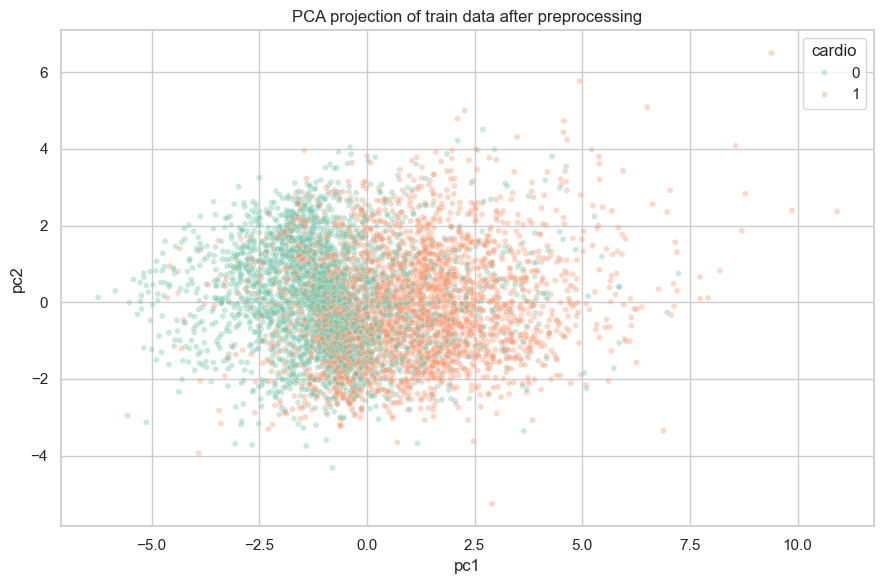

In [22]:
x_train_engineered = add_medical_features(x_train)
pca_preprocessor = build_preprocessor(
    ENGINEERED_NUMERIC_FEATURES,
    CATEGORICAL_FEATURES,
    use_pca=True,
    pca_components=2,
)
pca_projection = np.asarray(pca_preprocessor.fit_transform(x_train_engineered, y_train))

pca_frame = pd.DataFrame(
    {
        "pc1": pca_projection[:, 0],
        "pc2": pca_projection[:, 1],
        "cardio": y_train.to_numpy(),
    }
)

plot_sample = pca_frame.sample(min(6000, len(pca_frame)), random_state=RANDOM_STATE)

plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=plot_sample,
    x="pc1",
    y="pc2",
    hue="cardio",
    alpha=0.35,
    s=18,
)
plt.title("PCA projection of train data after preprocessing")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "pca_projection_train.png", dpi=150)
plt.show()

На PCA-графике классы частично смещены по `pc1`, но заметно перекрываются. Это совпадает с метриками: `Logistic Regression + PCA` дала ROC-AUC 0.7894 и не улучшила baseline.

## Финальная проверка выбранной модели

Выбираем лучшую модель по validation ROC-AUC, переобучаем ее на `train + validation` и один раз проверяем на test.

In [23]:
best_validation_row = comparison_table.sort_values("roc_auc", ascending=False).iloc[0]
best_experiment_id = cast(str, best_validation_row["experiment_id"])

x_train_val = pd.concat([x_train, x_val], axis=0)
y_train_val = pd.concat([y_train, y_val], axis=0)

if best_experiment_id == "baseline":
    baseline_model_name = cast(str, best_validation_row["model"])
    if baseline_model_name == "Logistic Regression":
        final_model = build_experiment_pipeline(
            LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
            feature_mode="raw",
        )
    elif baseline_model_name == "KNN":
        final_model = build_experiment_pipeline(
            KNeighborsClassifier(n_neighbors=15),
            feature_mode="raw",
        )
    else:
        raise ValueError(f"Unknown baseline model: {baseline_model_name}")
    final_model_name = baseline_model_name
    final_feature_mode = "raw"
    final_use_pca = False
else:
    best_experiment = next(item for item in experiments if item["experiment_id"] == best_experiment_id)
    final_model = cast(Pipeline, clone(fitted_estimators[best_experiment_id]))
    final_model_name = cast(str, best_experiment["model_name"])
    final_feature_mode = cast(str, best_experiment["feature_mode"])
    final_use_pca = cast(bool, best_experiment.get("use_pca", False))

final_model.fit(x_train_val, y_train_val)
final_metrics = evaluate_classifier(final_model, x_test, y_test)

final_results = pd.DataFrame(
    [
        {
            "experiment_id": best_experiment_id,
            "model": final_model_name,
            "split": "test",
            "feature_mode": final_feature_mode,
            "use_pca": final_use_pca,
            **final_metrics,
        }
    ]
)
final_results.to_csv(FINAL_RESULTS_PATH, index=False)

final_results

,experiment_id,model,split,feature_mode,use_pca,accuracy,precision,recall,f1,roc_auc
0,exp_06_hist_gradient_boosting_engineered,HistGradientBoosting,test,engineered,False,0.736249,0.752389,0.695934,0.723061,0.801619


Финальная модель `HistGradientBoosting` на test показала ROC-AUC 0.8016, F1 0.7231, Recall 0.6959, Precision 0.7524 и Accuracy 0.7362. Качество близко к validation, значит сильного переобучения по test не видно.

## Интерпретируемость финальной модели

Для финальной модели используем permutation importance на test-выборке. Такой подход подходит для всего `Pipeline`: он оценивает, насколько падает ROC-AUC, если перемешать значения конкретного исходного признака. Чем сильнее падение, тем важнее признак для качества модели.

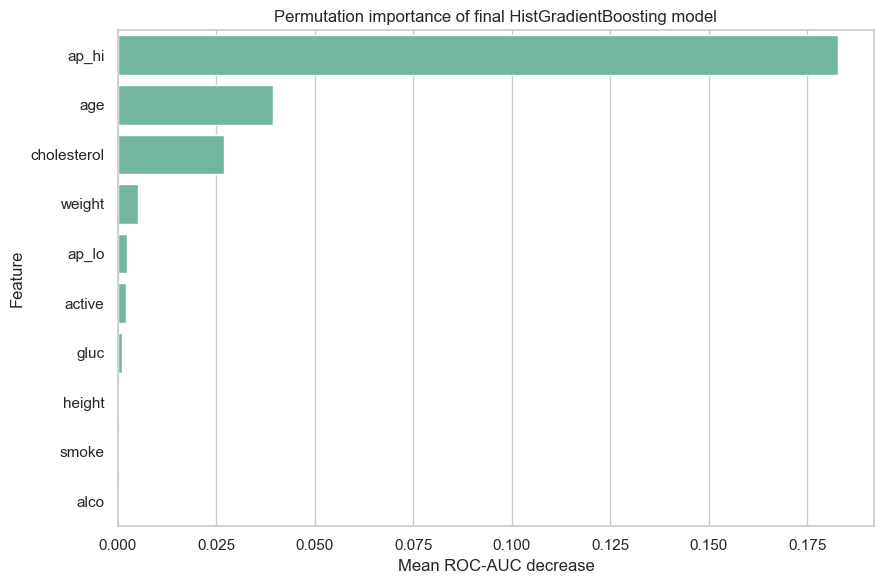

,feature,importance_mean,importance_std
0,ap_hi,0.182755,0.003230
1,age,0.039462,0.001013
2,cholesterol,0.027029,0.001411
3,weight,0.005129,0.000664
4,ap_lo,0.002376,0.000363
5,active,0.001948,0.000212
6,gluc,0.001128,0.000120
7,height,0.000356,0.000208
8,smoke,0.000346,0.000228
9,alco,0.000234,0.000143


In [24]:
importance_result = permutation_importance(
    final_model,
    x_test,
    y_test,
    scoring="roc_auc",
    n_repeats=5,
    random_state=RANDOM_STATE,
    n_jobs=1,
)

importance_table = (
    pd.DataFrame(
        {
            "feature": x_test.columns,
            "importance_mean": importance_result["importances_mean"],
            "importance_std": importance_result["importances_std"],
        }
    )
    .sort_values("importance_mean", ascending=False)
    .reset_index(drop=True)
)

IMPORTANCE_PATH = PROJECT_ROOT / "report" / "tables" / "permutation_importance.csv"
IMPORTANCE_FIGURE_PATH = PROJECT_ROOT / "report" / "images" / "permutation_importance.png"

importance_table.to_csv(IMPORTANCE_PATH, index=False)

plt.figure(figsize=(9, 6))
sns.barplot(
    data=importance_table.head(10),
    x="importance_mean",
    y="feature",
    orient="h",
)
plt.title("Permutation importance of final HistGradientBoosting model")
plt.xlabel("Mean ROC-AUC decrease")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig(IMPORTANCE_FIGURE_PATH, dpi=150)
plt.show()

importance_table


Сильнее всего на ROC-AUC влияет `ap_hi`: при перемешивании этого признака качество падает примерно на 0.183. Далее идут `age` с падением около 0.039 и `cholesterol` около 0.027. Остальные признаки влияют заметно слабее. Это хорошо согласуется с предметной областью: систолическое давление, возраст и холестерин являются ключевыми факторами риска сердечно-сосудистых заболеваний.

## Итоговый вывод

Во втором этапе были проверены 10 вариантов моделей и preprocessing-подходов. Лучший результат на validation показал `HistGradientBoosting` с feature engineering: ROC-AUC = 0.8039. Он обогнал baseline Logistic Regression, у которой ROC-AUC на validation был 0.7932.

На test выбранная модель сохранила близкое качество: ROC-AUC = 0.8016, F1 = 0.7231, Recall = 0.6959, Precision = 0.7524. Это значит, что улучшение относительно baseline выглядит устойчивым, а финальной моделью на этом этапе можно выбрать `HistGradientBoosting`.

Feature engineering оказался полезным для ансамблей и boosting-моделей. PCA, наоборот, не улучшил качество: классы на двумерной проекции сильно пересекаются, а `Logistic Regression + PCA` получила ROC-AUC ниже baseline.

Интерпретируемость через permutation importance показала, что главные признаки финальной модели: `ap_hi`, `age` и `cholesterol`. Это делает результат предметно осмысленным: модель сильнее всего опирается на систолическое давление, возраст пациента и уровень холестерина.